# Comparación entre Gini y Entropía

Sobre la misma variable categórica, `estado_civil_desc`, se calculan la **entropía de Shannon** (heterogeneidad) y el **coeficiente de Gini** de las frecuencias de las categorías (concentración), ponderado y sin ponderar, para todas las mujeres y solo para las que reportaron violencia de pareja. Las funciones están en `src/eda/comparacion_gini_entropia.py` y `src/eda/indices.py`.

## 1. Configuración

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from config.rutas import ARCHIVO_PROCESSED
from src.eda.comparacion_gini_entropia import PESO, VAR, VIOL, escenarios, indices_desde_frecuencias, tabla_indices
from src.visualization.graficas import lorenz
from src.visualization.graficas import aplicar_estilo, guardar_figura

aplicar_estilo()
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

## 2. Carga de datos

Se usa el dataset procesado (ruta en `config/rutas.py`).

In [2]:
df = pl.read_csv(ARCHIVO_PROCESSED)
faltantes = [c for c in (VAR, PESO, VIOL) if c not in df.columns]
assert not faltantes, f"Faltan columnas: {faltantes}"
print(f"Filas: {df.height:,} | Con violencia de pareja: {df.filter(pl.col(VIOL) == 1).height:,}")
print("Categorías de", VAR, ":", df[VAR].unique().sort().to_list())

Filas: 105,753 | Con violencia de pareja: 19,202
Categorías de estado_civil_desc : ['Casada', 'Divorciada', 'Separada', 'Soltera', 'Unión libre', 'Viuda']


## 3. Distribución de `estado_civil_desc`

In [3]:
frecs = escenarios(df)
comparacion = (
    frecs["Todas · ponderado"].select(VAR, pl.col("p").alias("todas_ponderada"))
    .join(frecs["Todas · sin ponderar"].select(VAR, pl.col("p").alias("todas_sin_ponderar")), on=VAR)
    .join(frecs["Con violencia · ponderado"].select(VAR, pl.col("p").alias("violencia_ponderada")), on=VAR, how="left")
    .join(frecs["Con violencia · sin ponderar"].select(VAR, pl.col("p").alias("violencia_sin_ponderar")), on=VAR, how="left")
    .fill_null(0.0)
)
comparacion

estado_civil_desc,todas_ponderada,todas_sin_ponderar,violencia_ponderada,violencia_sin_ponderar
str,f64,f64,f64,f64
"""Casada""",0.350244,0.399062,0.275744,0.309916
"""Unión libre""",0.1843,0.209999,0.152885,0.16993
"""Soltera""",0.261091,0.18721,0.165503,0.123112
"""Viuda""",0.089378,0.092158,0.113382,0.11504
"""Separada""",0.087641,0.081567,0.224373,0.206072
"""Divorciada""",0.027347,0.030004,0.068112,0.07593


## 4. Cálculo de índices

Prueba de cordura con casos extremos y después los índices de cada escenario. $H_{norm} = H/\log_2 k$ y $G_{norm} = G\cdot k/(k-1)$.

In [4]:
for nombre, n in {"Parejo (25/25/25/25)": [25, 25, 25, 25], "Domina una (97/1/1/1)": [97, 1, 1, 1], "Todo en una (100/0/0/0)": [100, 0, 0, 0]}.items():
    r = indices_desde_frecuencias(n)
    print(f"{nombre:28s} H_norm={r['H_norm']:.3f}  G_norm={r['G_norm']:.3f}")

Parejo (25/25/25/25)         H_norm=1.000  G_norm=0.000
Domina una (97/1/1/1)        H_norm=0.121  G_norm=0.960
Todo en una (100/0/0/0)      H_norm=0.000  G_norm=1.000


In [5]:
tabla = tabla_indices(frecs)
tabla

Índice,Todas · ponderado,Todas · sin ponderar,Con violencia · ponderado,Con violencia · sin ponderar
str,f64,f64,f64,f64
"""k""",6.0,6.0,6.0,6.0
"""H (bits)""",2.2468,2.218,2.4601,2.4412
"""H max (bits)""",2.585,2.585,2.585,2.585
"""H_norm""",0.8692,0.858,0.9517,0.9444
"""G""",0.3716,0.3876,0.2306,0.2483
"""G max""",0.8333,0.8333,0.8333,0.8333
"""G_norm""",0.446,0.4651,0.2767,0.298
"""Gini-Simpson""",0.7588,0.7456,0.8054,0.7985
"""IQV""",0.9105,0.8947,0.9664,0.9581


## 5. Gráficas

### 5.1 Distribución del estado civil

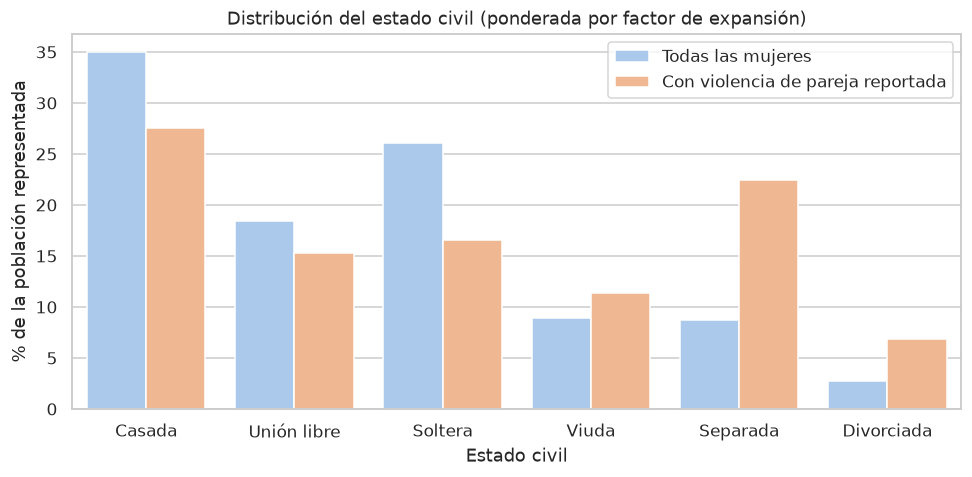

In [6]:
largo = (
    comparacion.select(VAR, pl.col("todas_ponderada").alias("Todas las mujeres"),
                       pl.col("violencia_ponderada").alias("Con violencia de pareja reportada"))
    .unpivot(index=VAR, variable_name="grupo", value_name="p")
    .with_columns(pl.col("p") * 100)
    .to_pandas()
)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=largo, x=VAR, y="p", hue="grupo", ax=ax)
ax.set_xlabel("Estado civil")
ax.set_ylabel("% de la población representada")
ax.set_title("Distribución del estado civil (ponderada por factor de expansión)")
ax.legend(title="")
fig.tight_layout()
guardar_figura(fig, "figA_distribucion_estado_civil")
plt.show()

### 5.2 Entropía vs Gini

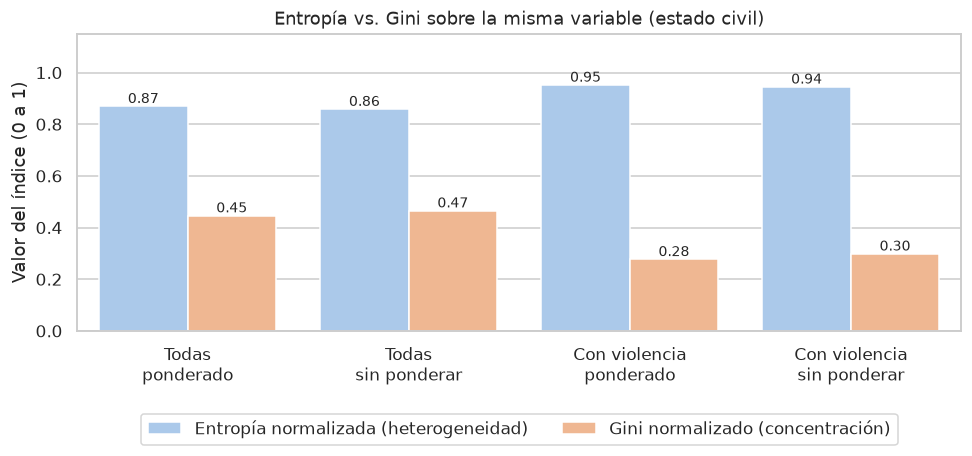

In [7]:
norm = (
    pl.DataFrame({"escenario": tabla.columns[1:]})
    .with_columns(
        pl.Series("Entropía normalizada (heterogeneidad)", [tabla.filter(pl.col("Índice") == "H_norm")[c][0] for c in tabla.columns[1:]]),
        pl.Series("Gini normalizado (concentración)", [tabla.filter(pl.col("Índice") == "G_norm")[c][0] for c in tabla.columns[1:]]),
    )
    .unpivot(index="escenario", variable_name="índice", value_name="valor")
    .to_pandas()
)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=norm, x="escenario", y="valor", hue="índice", ax=ax)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.2f", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_xticks(ax.get_xticks(), [t.get_text().replace(" · ", "\n") for t in ax.get_xticklabels()])
ax.set_xlabel("")
ax.set_ylabel("Valor del índice (0 a 1)")
ax.set_title("Entropía vs. Gini sobre la misma variable (estado civil)")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.25), ncols=2)
fig.tight_layout()
guardar_figura(fig, "figB_entropia_vs_gini")
plt.show()

### 5.3 Curva de Lorenz de las frecuencias

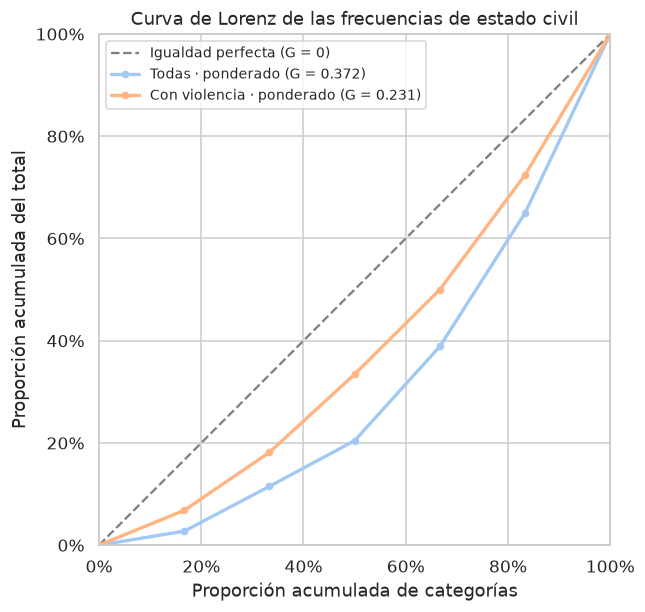

In [8]:
fig = lorenz({
    "Todas · ponderado": frecs["Todas · ponderado"]["n"].to_numpy(),
    "Con violencia · ponderado": frecs["Con violencia · ponderado"]["n"].to_numpy(),
}, "Curva de Lorenz de las frecuencias de estado civil", "Proporción acumulada de categorías")
guardar_figura(fig, "figC_lorenz_estado_civil")
plt.show()

## 6. Interpretación

- **Todas las mujeres (ponderado)**: entropía normalizada 0.869 (estado civil muy repartido) y Gini normalizado 0.446 (concentración moderada en casadas y solteras).
- **Con violencia (ponderado)**: entropía 0.952 y Gini 0.277; los casos están más repartidos entre estados civiles que la población, con más peso de separadas y divorciadas.
- Sin ponderar los valores cambian poco, así que ponderar no modifica la conclusión.
- La entropía mide qué tan impredecible es la categoría de una mujer elegida al azar; el Gini, qué tan desigual es el reparto entre categorías. Se mueven en sentidos opuestos, pero no son un espejo exacto (su suma va de 1.23 a 1.32).